In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model

spx = pd.read_csv("../data/spx.csv", index_col=0, parse_dates=True)
stable = pd.read_csv("../data/stable.csv", index_col=0, parse_dates=True)
tech = pd.read_csv("../data/tech.csv", index_col=0, parse_dates=True)
btc = pd.read_csv("../data/btc.csv", index_col=0, parse_dates=True)

spx_returns = np.log(spx["Close"] / spx["Close"].shift(1)).dropna()
stable_returns = np.log(stable["Close"] / stable["Close"].shift(1)).dropna()
tech_returns = np.log(tech["Close"] / tech["Close"].shift(1)).dropna()
btc_returns = np.log(btc["Close"] / btc["Close"].shift(1)).dropna()

for name, r in [("SPX", spx_returns), ("Stable", stable_returns), ("Tech", tech_returns), ("BTC", btc_returns)]:
    print(f"{name}: {len(r)} returns, mean={r.mean():.6f}, std={r.std():.6f}")

SPX: 2011 returns, mean=0.000476, std=0.011762
Stable: 2011 returns, mean=0.000324, std=0.011750
Tech: 2011 returns, mean=0.001978, std=0.031582
BTC: 2921 returns, mean=0.001554, std=0.037696


In [2]:
def rolling_garch_forecast(returns, refit_every=21, dist='t'):
    forecasts = []
    forecast_dates = []
    
    # Scale returns by 100 -- GARCH optimizers work better on this scale
    scaled_returns = returns * 100
    
    # Start after we have at least 252 days (~1 year) of history to fit on
    start = 252
    
    for i in range(start, len(scaled_returns), refit_every):
        train_data = scaled_returns.iloc[:i]
        
        model = arch_model(train_data, vol='GARCH', p=1, q=1, dist=dist)
        fitted = model.fit(disp='off')
        
        # Forecast the next `refit_every` days using this fitted model
        horizon = min(refit_every, len(scaled_returns) - i)
        forecast = fitted.forecast(horizon=horizon, reindex=False)
        
        variances = forecast.variance.values[0]  # in scaled (returns*100) units
        
        for h in range(horizon):
            forecasts.append(variances[h])
            forecast_dates.append(scaled_returns.index[i + h])
    
    result = pd.Series(forecasts, index=forecast_dates)
    return result

In [3]:
spx_garch = rolling_garch_forecast(spx_returns)
print(f"SPX: {len(spx_garch)} forecasts generated")

stable_garch = rolling_garch_forecast(stable_returns)
print(f"Stable: {len(stable_garch)} forecasts generated")

tech_garch = rolling_garch_forecast(tech_returns)
print(f"Tech: {len(tech_garch)} forecasts generated")

btc_garch = rolling_garch_forecast(btc_returns)
print(f"BTC: {len(btc_garch)} forecasts generated")

SPX: 1759 forecasts generated
Stable: 1759 forecasts generated
Tech: 1759 forecasts generated
BTC: 2669 forecasts generated


In [4]:
# Forecasts are in scaled (returns*100) variance units -- convert back to raw variance, then to annualized vol
spx_garch_vol = np.sqrt(spx_garch) / 100 * np.sqrt(252) * 100
stable_garch_vol = np.sqrt(stable_garch) / 100 * np.sqrt(252) * 100
tech_garch_vol = np.sqrt(tech_garch) / 100 * np.sqrt(252) * 100
btc_garch_vol = np.sqrt(btc_garch) / 100 * np.sqrt(252) * 100

for name, vol in [("SPX", spx_garch_vol), ("Stable", stable_garch_vol), ("Tech", tech_garch_vol), ("BTC", btc_garch_vol)]:
    print(f"{name} GARCH annualized vol sample:\n{vol.head()}\n")

SPX GARCH annualized vol sample:
2018-01-04    8.016677
2018-01-05    7.809160
2018-01-08    7.754944
2018-01-09    7.740953
2018-01-10    7.737354
dtype: float64

Stable GARCH annualized vol sample:
2018-01-04    9.065632
2018-01-05    9.067447
2018-01-08    9.069070
2018-01-09    9.070521
2018-01-10    9.071818
dtype: float64

Tech GARCH annualized vol sample:
2018-01-04    53.936912
2018-01-05    50.824776
2018-01-08    48.650733
2018-01-09    47.153384
2018-01-10    46.133360
dtype: float64

BTC GARCH annualized vol sample:
2017-09-11    81.090941
2017-09-12    82.710558
2017-09-13    84.299062
2017-09-14    85.858182
2017-09-15    87.389491
dtype: float64



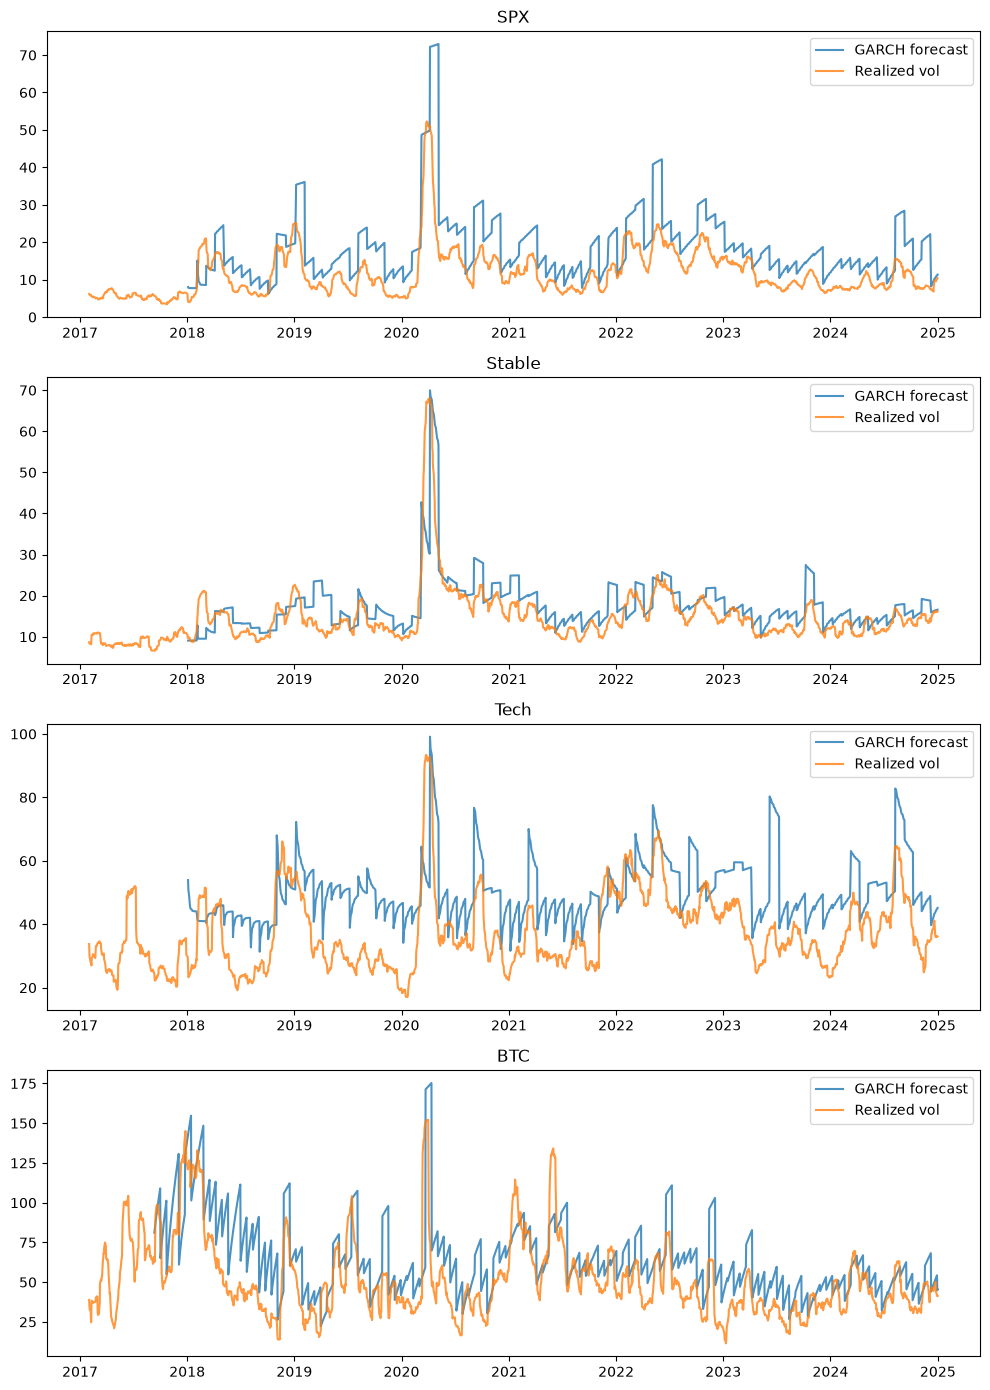

In [5]:
realized_vol = pd.read_csv("../data/realized_volatility.csv", index_col=0, parse_dates=True)

fig, axes = plt.subplots(4, 1, figsize=(10, 14))

pairs = [
    ("SPX", spx_garch_vol, realized_vol["spx"]),
    ("Stable", stable_garch_vol, realized_vol["stable"]),
    ("Tech", tech_garch_vol, realized_vol["tech"]),
    ("BTC", btc_garch_vol, realized_vol["btc"])
]

for ax, (name, garch, realized) in zip(axes, pairs):
    ax.plot(garch.index, garch, label="GARCH forecast", alpha=0.8)
    ax.plot(realized.index, realized, label="Realized vol", alpha=0.8)
    ax.set_title(name)
    ax.legend()

plt.tight_layout()
plt.show()

In [6]:
def rmse(forecast, realized):
    aligned = pd.concat([forecast, realized], axis=1, join="inner").dropna()
    aligned.columns = ["forecast", "realized"]
    return np.sqrt(((aligned["forecast"] - aligned["realized"]) ** 2).mean())

pairs = [
    ("SPX", spx_garch_vol, realized_vol["spx"]),
    ("Stable", stable_garch_vol, realized_vol["stable"]),
    ("Tech", tech_garch_vol, realized_vol["tech"]),
    ("BTC", btc_garch_vol, realized_vol["btc"])
]

for name, garch, realized in pairs:
    error = rmse(garch, realized)
    print(f"{name} GARCH RMSE vs realized vol: {error:.2f}")

SPX GARCH RMSE vs realized vol: 8.59
Stable GARCH RMSE vs realized vol: 5.28
Tech GARCH RMSE vs realized vol: 15.68
BTC GARCH RMSE vs realized vol: 21.92


In [7]:
garch_forecasts = pd.DataFrame({
    "spx": spx_garch_vol,
    "stable": stable_garch_vol,
    "tech": tech_garch_vol,
    "btc": btc_garch_vol
})

garch_forecasts.to_csv("../data/garch_forecasts.csv")
print(f"Saved {len(garch_forecasts)} rows to garch_forecasts.csv")
garch_forecasts.head()

Saved 2669 rows to garch_forecasts.csv


,spx,stable,tech,btc
2017-09-11,NaN,NaN,NaN,81.090941
2017-09-12,NaN,NaN,NaN,82.710558
2017-09-13,NaN,NaN,NaN,84.299062
2017-09-14,NaN,NaN,NaN,85.858182
2017-09-15,NaN,NaN,NaN,87.389491
